In [1]:
import numpy as np
import torch 
import gymnasium as gym
import matplotlib.pyplot as plt
import dill

from copy import deepcopy
from tqdm import tqdm
from four_room.env import FourRoomsEnv
from four_room.wrappers import gym_wrapper, gym_wrapper_state
from four_room.constants import state_to_q, state_to_q_np
from rnd_exploration.dataset import State
from four_room.constants import train_config, val_config, test_config, size
from uvu.uvu import UVU
from dqn.model import DQN
from utils.episode import LastEpisode
from dqn.counter import MovingCountBasedUncertainty
from utils.record_scores import record_uvu_scores, record_dqn_scores
from four_room.utils import obs_to_state, obs_to_img, reverse_doors
from four_room.shortest_path import find_all_action_values

gym.register('MiniGrid-FourRooms-v1', FourRoomsEnv)


%load_ext autoreload
%autoreload 2

c:\Users\garga\Documents\Uni\RND DQN\four_room\venv\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment MiniGrid-FourRooms-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [2]:
def get_state(obs, use_cnn):
    if use_cnn:
        return obs_to_state(obs)
    else:
        first = [int(item) for item in obs[:5]]
        return tuple(first + list(reverse_doors(obs)))

In [23]:
use_cnn = True

env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=use_cnn
    )
    
val_env = gym_wrapper_state(gym.make(
        'MiniGrid-FourRooms-v1', 
        agent_pos= train_config['agent positions'],
        goal_pos = train_config['goal positions'],
        doors_pos = train_config['topologies'],
        agent_dir = train_config['agent directions'],
        size=size
    ),
)

obs, _ = env.reset()
obs2, _ = env.reset()

using DQNBaseAction
using DQNBaseAction


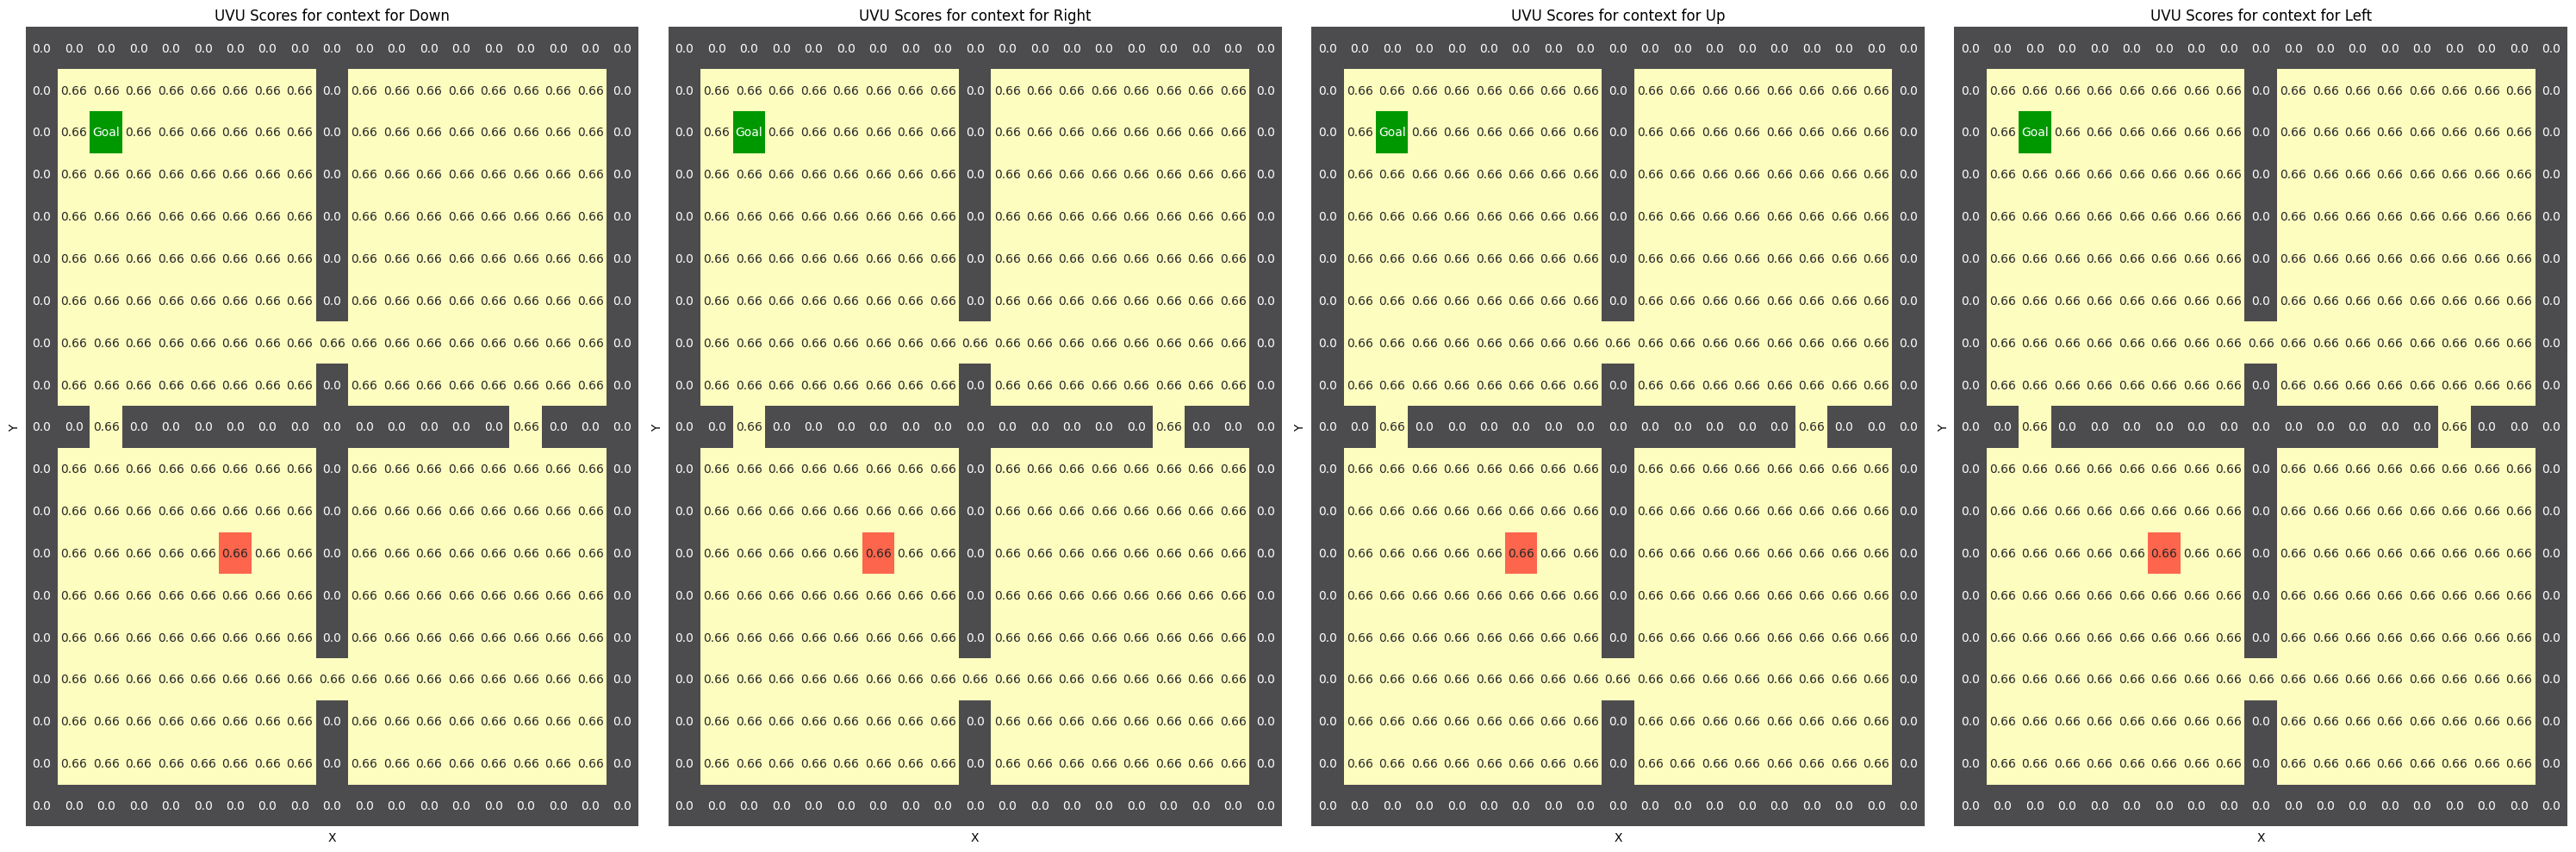

In [ ]:
from plot_interactive import find_states, plot_env_heatmap

agent = UVU(
    env=env,
    val_env=val_env,
    tau=0.5,
    lr=1e-4,
    gamma=0.95,
    boostrap_prob=0.9,
    device='cuda',
    concat={"action": True, "dual": False},
    use_cnn=use_cnn,
    use_action=True, 
    use_dual=False, 
    use_norm=True, 
    hidden_layers=[512, 512, 512],
    hidden_layers_g=[512, 512, 512],
    init_func='kaiming',
    scale=1, 
    num_heads=512,
)

# agent = DQN(
#     env=env,
#     val_env=val_env,
#     capacity=1000,
#     tau=0.001,
#     lr=3e-4,
#     device='cuda',
#     use_cnn=True,
#     cnn_features=1024,
#     hidden_layers=[1024, 2048, 1024],
#     residual=True
# )

fig, axes = plt.subplots(1, 4, figsize=(30, 10))
context = 0
_, _, uvu_scores = record_uvu_scores(agent, context, 0, render=True, use_cnn=use_cnn)
uvu_scores = uvu_scores 
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False,
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)


plt.tight_layout() 


In [36]:
env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=use_cnn
    )

done = False
context = 0
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
loss = 0
postfix = {}
for step in (pbar := tqdm(range(1, 20000))):
    state = get_state(obs, use_cnn=use_cnn)
    q = state_to_q_np[context, state[0], state[1], state[2]]
    action = q.argmax() if isinstance(q, np.ndarray) else np.array(q).argmax()
    
    obs_prime, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    state_next = get_state(obs_prime, use_cnn=use_cnn)
    q_next = state_to_q_np[context, state_next[0], state_next[1], state_next[2]]
    next_action = q_next.argmax()
        
    agent.buffer.update(obs, action, reward, obs_prime, next_action, int(done), q_value=q)
    obs = obs_prime

    if done:
        env.get_wrapper_attr('set_context')(context)
        obs, _ = env.reset()
    
    if agent.buffer.size > 128:
        loss = agent.update_step(128)
        postfix["loss"] = loss.item()
        pbar.set_postfix(postfix)
        agent.soft_update()
    

100%|██████████| 19999/19999 [06:42<00:00, 49.66it/s, loss=3.33e-8]


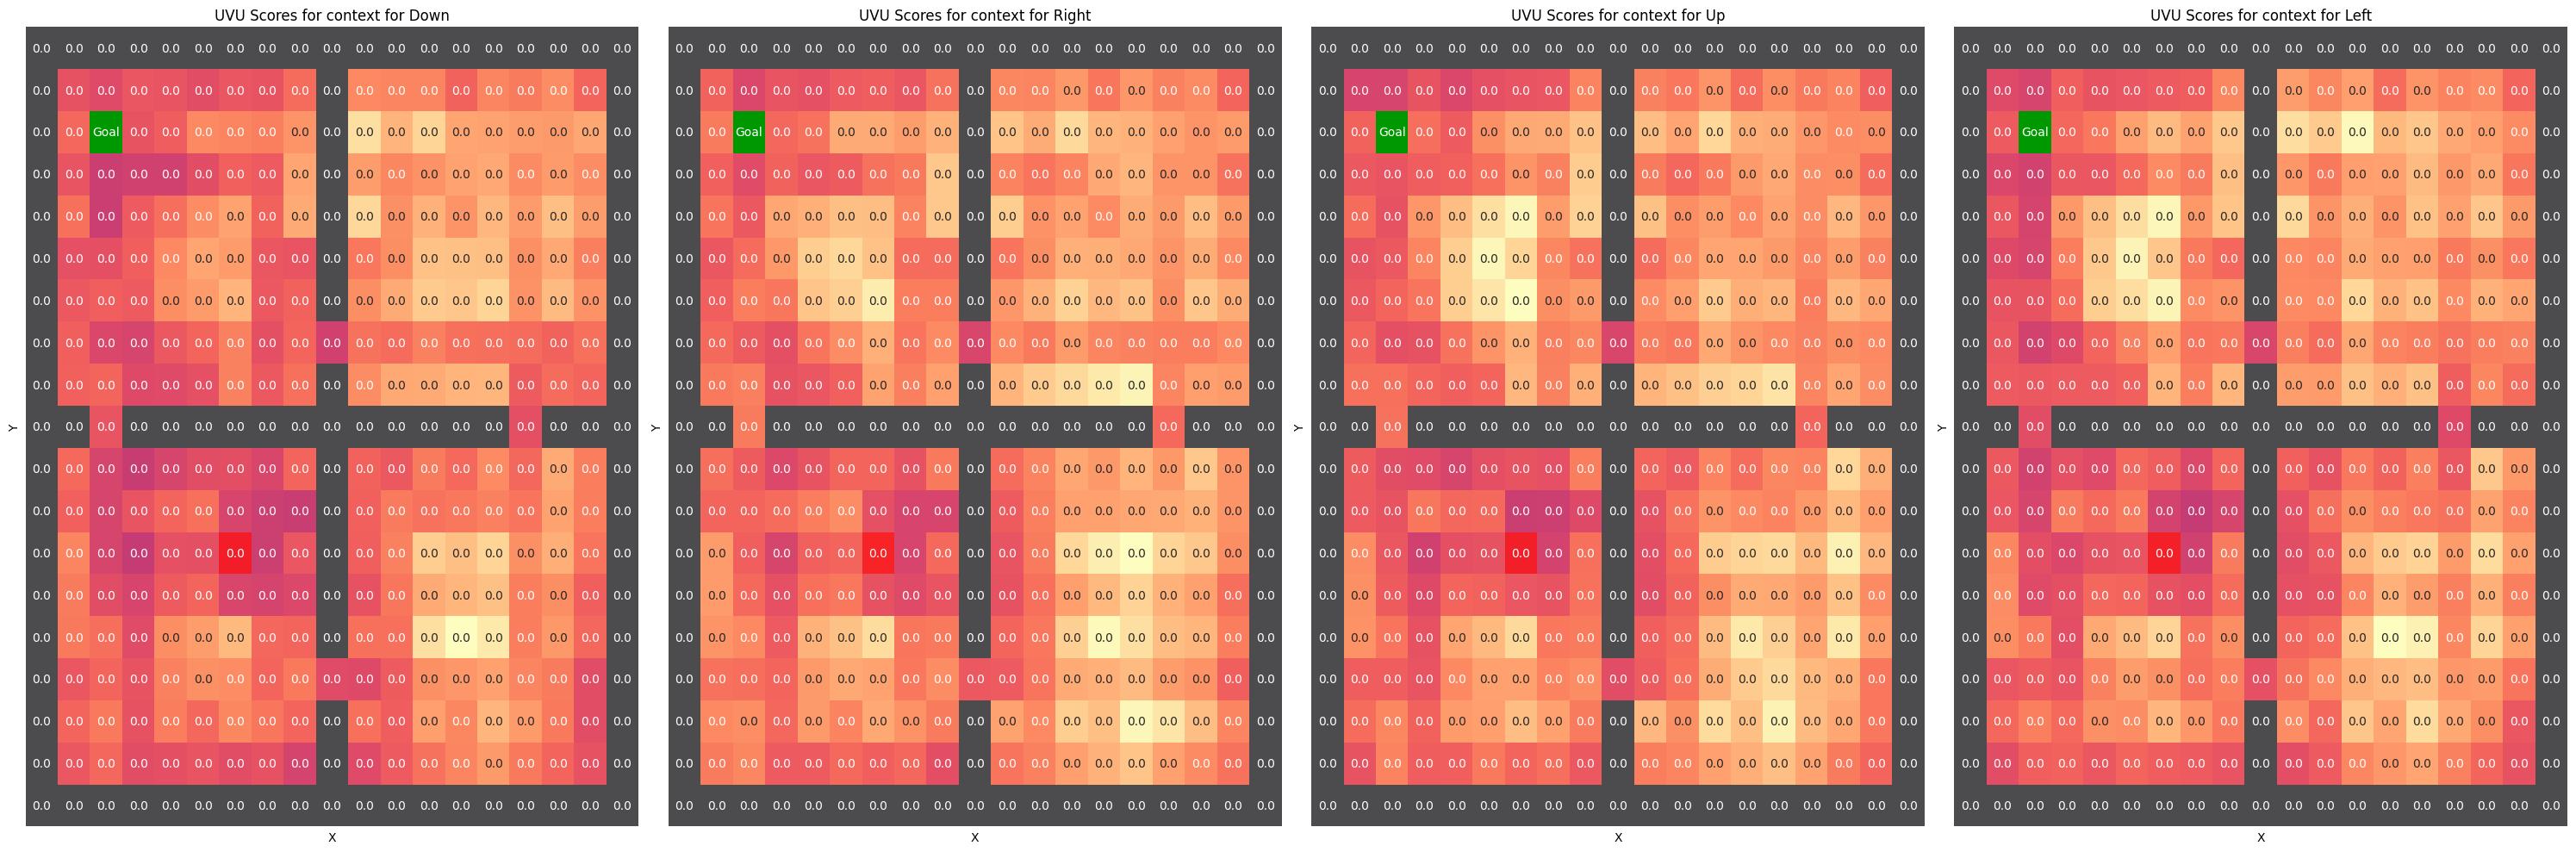

In [37]:
from plot_interactive import find_states, plot_env_heatmap

fig, axes = plt.subplots(1, 4, figsize=(30, 10))
context = 0
_, _, uvu_scores = record_uvu_scores(agent, context, 0, use_cnn=use_cnn)
uvu_scores = uvu_scores
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)


plt.tight_layout() 


In [ ]:
use_cnn = True

env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=use_cnn
    )
    
val_env = gym_wrapper_state(gym.make(
        'MiniGrid-FourRooms-v1', 
        agent_pos= train_config['agent positions'],
        goal_pos = train_config['goal positions'],
        doors_pos = train_config['topologies'],
        agent_dir = train_config['agent directions'],
        size=size
    ),
)

obs, _ = env.reset()
obs2, _ = env.reset()

using DQNBaseAction


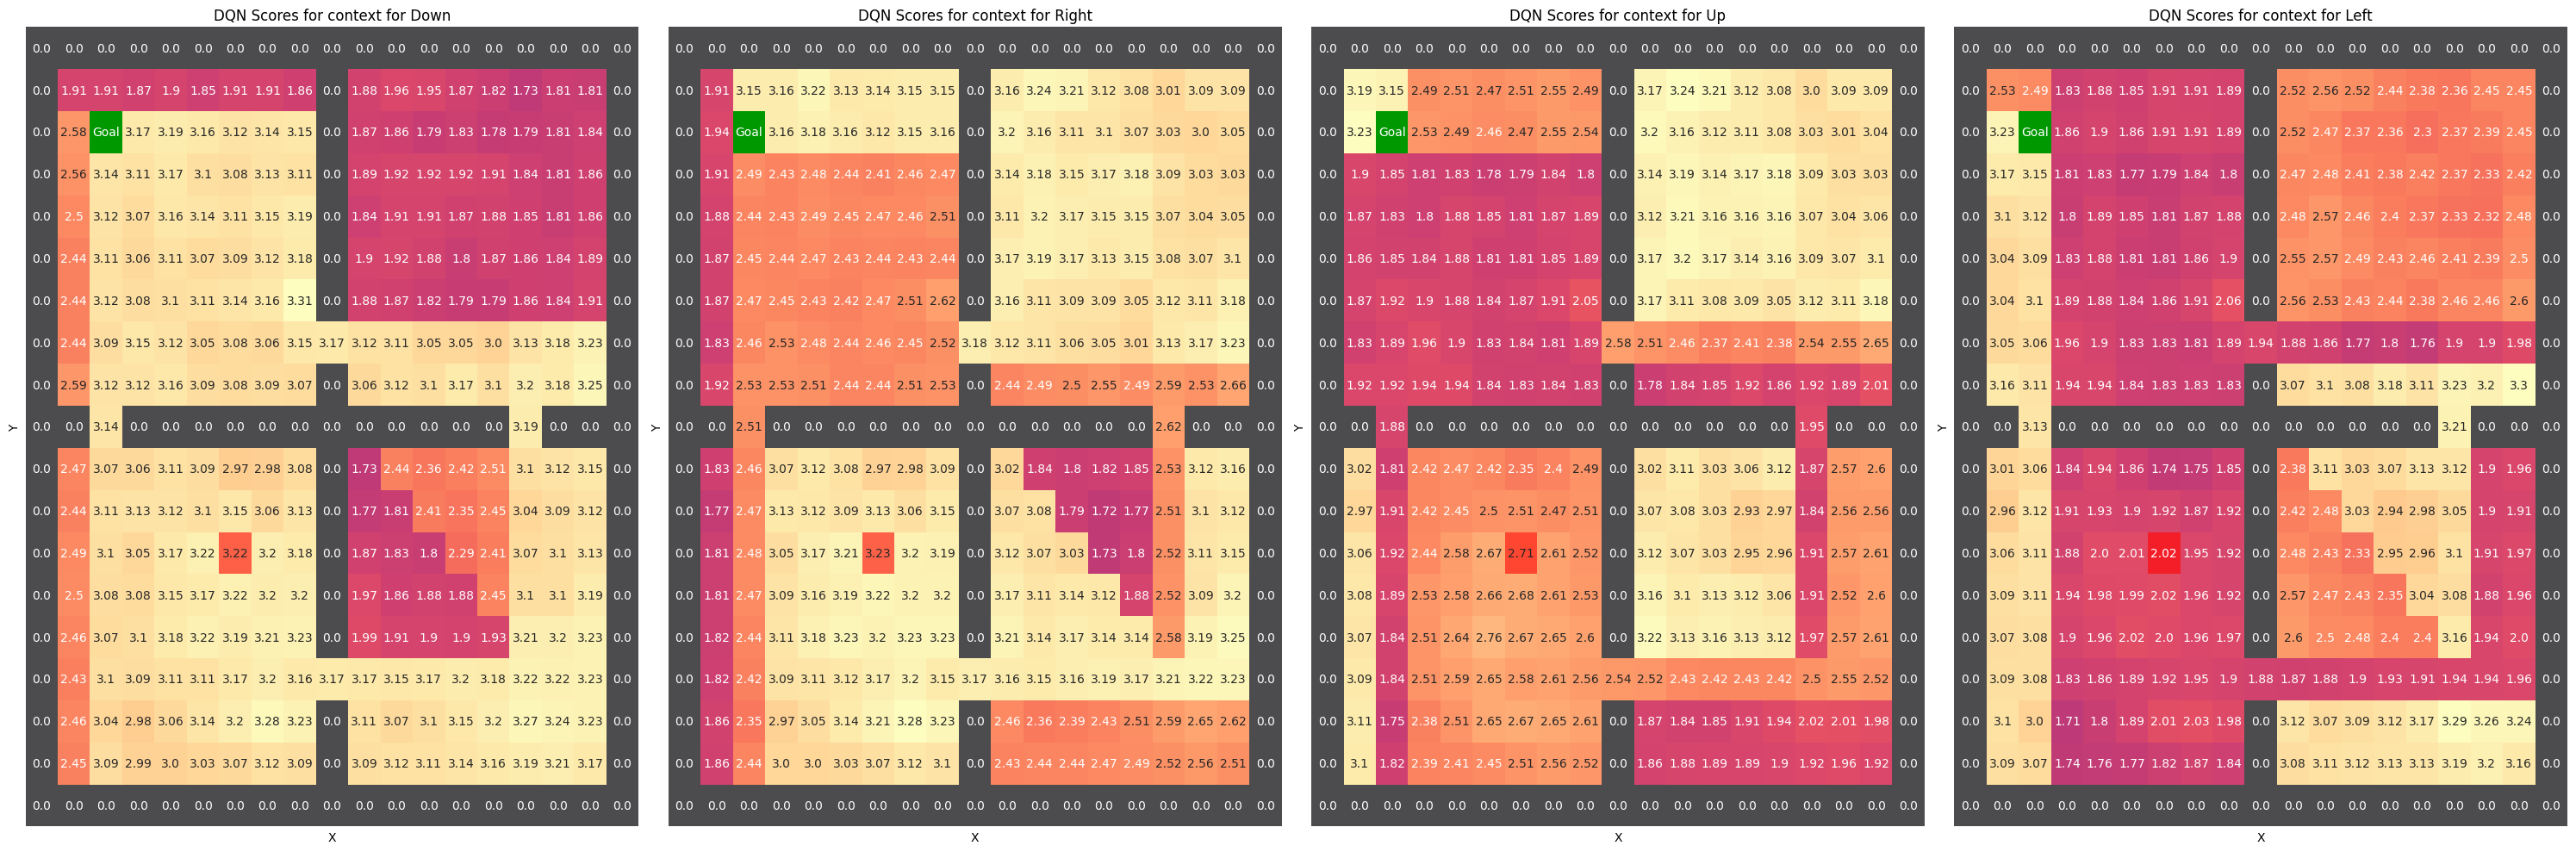

In [81]:
from plot_interactive import find_states, plot_env_heatmap

agent = DQN(
    env,
    val_env=val_env,
    tau=0.05,
    lr=3e-4,
    gamma=0.99,
    device='cuda',
    use_cnn=use_cnn,
    use_action=True, 
    use_dual=False, 
    use_norm=False, 
    hidden_layers=[256, 256],
    init_func='orthogonal',
    scale=1
)

fig, axes = plt.subplots(1, 4, figsize=(30, 10))
context = 0
_, _, uvu_scores = record_dqn_scores(agent, context, 0, use_cnn=use_cnn)
uvu_scores = uvu_scores 
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False,
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)


plt.tight_layout() 


In [82]:
env = gym_wrapper_state(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        use_cnn=use_cnn
    )

done = False
context = 0
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
for step in tqdm(range(1, 5000)):
    state = get_state(obs, use_cnn=use_cnn)
    q = state_to_q_np[context, state[0], state[1], state[2]]
    action = q.argmax() if isinstance(q, np.ndarray) else np.array(q).argmax()
    
    obs_prime, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    state_next = get_state(obs_prime, use_cnn=use_cnn)
    q_next = state_to_q_np[context, state_next[0], state_next[1], state_next[2]]
    next_action = q_next.argmax()
        
    agent.buffer.update(obs, action, reward, obs_prime, next_action, int(done), q_value=q)
    obj_moving_tuple = (context, *state[:3])
    agent.counter.add(obj_moving_tuple, step)
    obs = obs_prime
    if done:
        env.get_wrapper_attr('set_context')(context)
        obs, _ = env.reset()
        
    
    if agent.buffer.size > 128:
        agent.update_step(128)
        agent.soft_update()
    

100%|██████████| 4999/4999 [01:18<00:00, 63.66it/s]


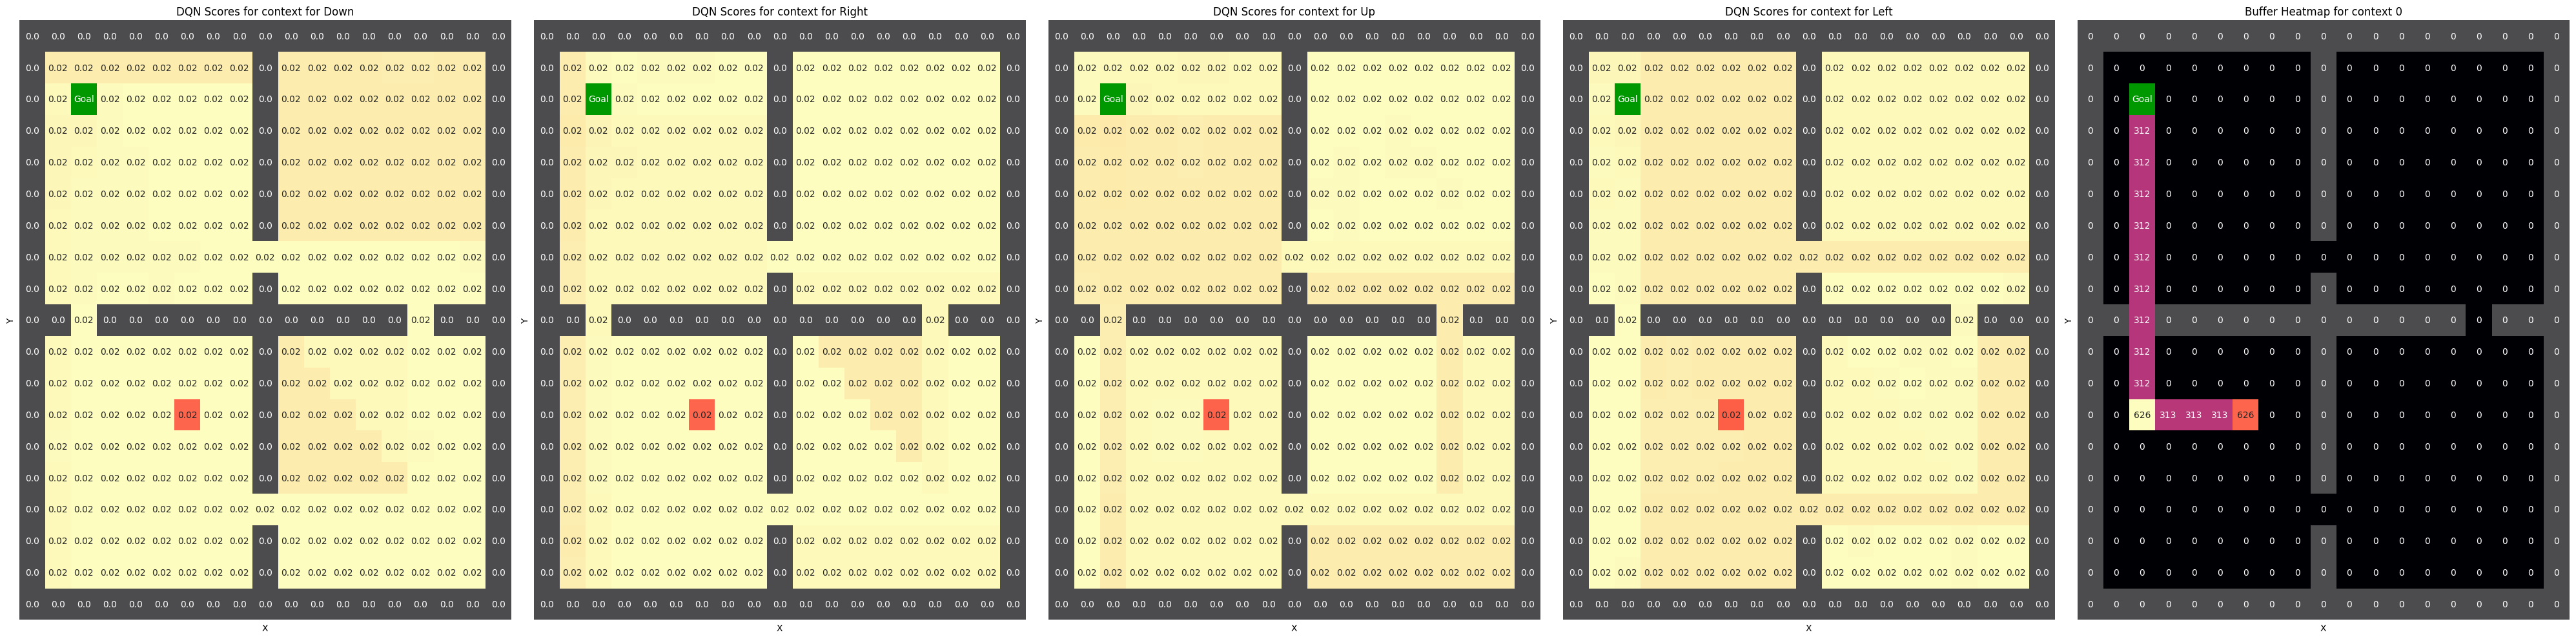

In [83]:
from plot_interactive import find_states, plot_env_heatmap, find_states

fig, axes = plt.subplots(1, 5, figsize=(40, 10))
context = 0
_, _, uvu_scores = record_dqn_scores(agent, context, 0, use_cnn=use_cnn)
uvu_scores = uvu_scores / 100
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

relevant_buffer = np.zeros((200, 19, 19))
relevant_buffer_states = find_states(
    agent.counter.all_states, 5000, agent.buffer.capacity
)
for state in relevant_buffer_states:
    relevant_buffer[*state] += 1

plot_env_heatmap(
    relevant_buffer[context],
    context_info,
    "Buffer Counts",
    f"Buffer Heatmap for context {context}",
    axes[4],
)

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'DQN Scores',
    f'DQN Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)

plt.tight_layout() 
